# High-Resolution Real Regrid Local-Structure Diagnostic

Goal: test whether lagged local conditioning should reuse the same max-min local structure from the current time, or recompute nearest neighbors directly in the lagged real-data locations.

This notebook deliberately separates the geometry question from full Vecchia fitting:

1. Load one real 2024 July day pattern from the GEMS TCO source-location pickle.
2. Snap real source locations to a very high-resolution reference grid (`lat x100`, `lon x10`) for matching diagnostics.
3. Regrid to the modeling grid (`0.044 x 0.063`) using a one-to-one nearest-cell assignment with half-cell tolerance.
4. Build the usual max-min ordering on the regular modeling grid.
5. Compare lagged candidate sets:
   - `same_structure_anchor_plus_nn`: reuse the current-time base-cell local graph at lag time.
   - `lag_recompute_actual_target_nn`: recompute NN in the actual lagged real source locations around the current target coordinate.
   - `lag_recompute_base_target_nn`: recompute NN around the matched base-grid target coordinate.
   - shifted/fresh and hybrid controls for context.

The central readout is not whether correlation-top-k itself should be used in production. It is whether the fixed same-structure lag local set is losing meaningful correlation relative to recomputing lag-time NN after realistic matching/regridding.

In [1]:
import os
import sys
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import BallTree

AMAREL_SRC = "/home/jl2815/tco"
LOCAL_SRC = "/Users/joonwonlee/Documents/GEMS_TCO-1/src"
_src = AMAREL_SRC if os.path.exists(AMAREL_SRC) else LOCAL_SRC
sys.path.insert(0, _src)

from GEMS_TCO import configuration as config
from GEMS_TCO import orderings as _orderings

is_amarel = os.path.exists(config.amarel_data_load_path)
DATA_PATH = config.amarel_data_load_path if is_amarel else config.mac_data_load_path

print("SRC:", _src)
print("DATA_PATH:", DATA_PATH)

SRC: /Users/joonwonlee/Documents/GEMS_TCO-1/src
DATA_PATH: /Users/joonwonlee/Documents/GEMS_DATA/


## Settings

The base grid is the high-resolution modeling grid discussed in the notes: `lat=0.044`, `lon=0.063`. The high-resolution snap grid is not materialized as a huge array; it is computed by arithmetic rounding to keep the diagnostic light.

In [2]:
YEAR = "2024"
MONTH = 7
LAT_RANGE = (-3.0, 2.0)
LON_RANGE = (121.0, 131.0)

DELTA_LAT_BASE = 0.044
DELTA_LON_BASE = 0.063
LAT_FACTOR = 100
LON_FACTOR = 10
T_STEPS = 8

MM_COND_NUMBER = 100
MIN_ORDER_POS = 40
TARGET_T_IDX = 4  # compare against lag 1 and lag 2; must be >= 2
LAGS = [1, 2]
LAG_SET_SIZE = {1: 18, 2: 15}
TOP_K_BY_LAG = LAG_SET_SIZE.copy()

MAX_TARGETS = 1500  # None = all eligible targets; raise to 3000-5000 after a smoke run
SEED = 42
RANDOM_DAY_INDEX = None  # None = random day from the month; set an integer for reproducible day choice

# Correlation-evaluation parameters. These are diagnostic parameters, not fitted estimates.
TRUE_DICT_BASE = {
    "sigmasq": 10.0,
    "range_lat": 0.30,
    "range_lon": 0.40,
    "range_time": 2.0,
    "advec_lat": 0.08,
    "nugget": 2.5,
}
EVAL_ADVEC_LON_LIST = [-0.06, -0.10, -0.126, -0.16]
PRED_LAG1_LON_OFFSETS = [0.00, 0.063, 0.126, 0.189]

# Hybrid context budgets. These are diagnostic set sizes, not final fitting configs.
HYBRID_BUDGET_BY_LAG = {
    1: {"local": 8, "fresh": 4},
    2: {"local": 4, "fresh": 3},
}

SAVE_CSV = True
OUT_PREFIX = "sim_vecchia_irregular2024_highres_local_structure_regrid_050226"

print(f"base grid step: lat={DELTA_LAT_BASE}, lon={DELTA_LON_BASE}")
print(f"base half-cell tolerance: lat={DELTA_LAT_BASE/2}, lon={DELTA_LON_BASE/2}")
print(f"high-res snap step: lat={DELTA_LAT_BASE/LAT_FACTOR}, lon={DELTA_LON_BASE/LON_FACTOR}")
print("eval advec_lon values:", EVAL_ADVEC_LON_LIST)
print("predicted lag-1 east offsets:", PRED_LAG1_LON_OFFSETS)
print("predicted lag-1 offsets in base lon cells:", [round(v / DELTA_LON_BASE, 3) for v in PRED_LAG1_LON_OFFSETS])

base grid step: lat=0.044, lon=0.063
base half-cell tolerance: lat=0.022, lon=0.0315
high-res snap step: lat=0.00043999999999999996, lon=0.0063
eval advec_lon values: [-0.06, -0.1, -0.126, -0.16]
predicted lag-1 east offsets: [0.0, 0.063, 0.126, 0.189]
predicted lag-1 offsets in base lon cells: [0.0, 1.0, 2.0, 3.0]


## Load One Real-Day Source Pattern

The source-location pickle provides the real irregular locations for each time slot. We choose one day in July 2024 and keep only the analysis bounding box.

In [3]:
def load_tco_grid_map(data_path, year=YEAR, month=MONTH):
    yy = str(year)[2:]
    path = Path(data_path) / f"pickle_{year}" / f"tco_grid_{yy}_{month:02d}.pkl"
    if not path.exists():
        raise FileNotFoundError(path)
    with open(path, "rb") as f:
        raw = pickle.load(f)
    return raw, path

def lat_lon_columns(df):
    lat_col = "Source_Latitude" if "Source_Latitude" in df.columns else "Latitude"
    lon_col = "Source_Longitude" if "Source_Longitude" in df.columns else "Longitude"
    return lat_col, lon_col

def filter_source_bbox(df, lat_range=LAT_RANGE, lon_range=LON_RANGE):
    lat_col, lon_col = lat_lon_columns(df)
    out = df.copy()
    out[lat_col] = pd.to_numeric(out[lat_col], errors="coerce")
    out[lon_col] = pd.to_numeric(out[lon_col], errors="coerce")
    mask = (
        out[lat_col].between(min(lat_range), max(lat_range))
        & out[lon_col].between(min(lon_range), max(lon_range))
    )
    return out.loc[mask].reset_index(drop=True)

def extract_source_coords(df):
    if df.empty:
        return np.empty((0, 2), dtype=np.float64)
    lat_col, lon_col = lat_lon_columns(df)
    src = df[[lat_col, lon_col]].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=np.float64)
    src = src[~np.isnan(src).any(axis=1)]
    return src

raw_tco_map, raw_path = load_tco_grid_map(DATA_PATH, YEAR, MONTH)
all_keys = sorted(raw_tco_map.keys())
n_days = len(all_keys) // T_STEPS
rng = np.random.default_rng(SEED)
if RANDOM_DAY_INDEX is None:
    DAY_INDEX = int(rng.integers(0, n_days))
else:
    DAY_INDEX = int(RANDOM_DAY_INDEX)
DAY_INDEX = max(0, min(DAY_INDEX, n_days - 1))
day_keys = all_keys[DAY_INDEX * T_STEPS : (DAY_INDEX + 1) * T_STEPS]
ref_day_map = {k: filter_source_bbox(raw_tco_map[k]) for k in day_keys}

print("loaded:", raw_path)
print("available slots:", len(all_keys), "days:", n_days)
print("selected DAY_INDEX:", DAY_INDEX)
print("day keys:", day_keys)
print("rows per selected slot:", {k: len(v) for k, v in ref_day_map.items()})
print("columns:", list(next(iter(ref_day_map.values())).columns)[:20])

loaded: /Users/joonwonlee/Documents/GEMS_DATA/pickle_2024/tco_grid_24_07.pkl
available slots: 248 days: 31
selected DAY_INDEX: 2
day keys: ['y24m07day03_hm00:53', 'y24m07day03_hm01:53', 'y24m07day03_hm02:53', 'y24m07day03_hm03:53', 'y24m07day03_hm04:48', 'y24m07day03_hm05:48', 'y24m07day03_hm06:48', 'y24m07day03_hm07:48']
rows per selected slot: {'y24m07day03_hm00:53': 18067, 'y24m07day03_hm01:53': 17670, 'y24m07day03_hm02:53': 16698, 'y24m07day03_hm03:53': 16863, 'y24m07day03_hm04:48': 17088, 'y24m07day03_hm05:48': 17760, 'y24m07day03_hm06:48': 18104, 'y24m07day03_hm07:48': 18102}
columns: ['Latitude', 'Longitude', 'ColumnAmountO3', 'Hours_elapsed', 'Source_Latitude', 'Source_Longitude']


## Build Base Grid And Match/Regrid Real Locations

The base-grid assignment is one-to-one: if several real observations fall into the same base cell, the closest source location wins. Any winner outside the half-cell tolerance is dropped.

The high-resolution snap diagnostic checks how close each source location is to the `lat x100`, `lon x10` snap grid. This avoids building a huge high-res mesh.

In [4]:
def make_axis(start, stop, step):
    # Add a small epsilon so the intended endpoint is not lost to floating-point roundoff.
    return np.round(np.arange(start, stop + step * 0.25, step, dtype=np.float64), 10)

def build_base_grid(lat_range=LAT_RANGE, lon_range=LON_RANGE):
    lats = make_axis(min(lat_range), max(lat_range), DELTA_LAT_BASE)
    lons = make_axis(min(lon_range), max(lon_range), DELTA_LON_BASE)
    g_lat, g_lon = np.meshgrid(lats, lons, indexing="ij")
    coords = np.column_stack([g_lat.ravel(), g_lon.ravel()]).astype(np.float64)
    return lats, lons, coords

def nearest_rectilinear_cell(coords, lats, lons):
    coords = np.asarray(coords, dtype=np.float64)
    lat_idx = np.rint((coords[:, 0] - lats[0]) / DELTA_LAT_BASE).astype(np.int64)
    lon_idx = np.rint((coords[:, 1] - lons[0]) / DELTA_LON_BASE).astype(np.int64)
    in_bounds = (lat_idx >= 0) & (lat_idx < len(lats)) & (lon_idx >= 0) & (lon_idx < len(lons))
    cell = np.full(len(coords), -1, dtype=np.int64)
    cell[in_bounds] = lat_idx[in_bounds] * len(lons) + lon_idx[in_bounds]
    return cell, in_bounds

def snap_to_highres(coords):
    coords = np.asarray(coords, dtype=np.float64)
    dlat = DELTA_LAT_BASE / LAT_FACTOR
    dlon = DELTA_LON_BASE / LON_FACTOR
    lat0 = min(LAT_RANGE)
    lon0 = min(LON_RANGE)
    lat_snap = lat0 + np.rint((coords[:, 0] - lat0) / dlat) * dlat
    lon_snap = lon0 + np.rint((coords[:, 1] - lon0) / dlon) * dlon
    snapped = np.column_stack([lat_snap, lon_snap])
    err = coords - snapped
    return snapped, err, dlat, dlon

def assign_sources_to_base_cells(src, base_coords, lats, lons):
    n_grid = len(base_coords)
    assignment = np.full(n_grid, -1, dtype=np.int64)
    best_sqdist = np.full(n_grid, np.inf, dtype=np.float64)
    if len(src) == 0:
        return assignment, pd.DataFrame()

    cell, in_bounds = nearest_rectilinear_cell(src, lats, lons)
    valid_obs = np.where(in_bounds & (cell >= 0))[0]
    for obs_i in valid_obs:
        c = int(cell[obs_i])
        dlat = src[obs_i, 0] - base_coords[c, 0]
        dlon = src[obs_i, 1] - base_coords[c, 1]
        if abs(dlat) > DELTA_LAT_BASE / 2 or abs(dlon) > DELTA_LON_BASE / 2:
            continue
        sq = dlat * dlat + dlon * dlon
        if sq < best_sqdist[c]:
            assignment[c] = obs_i
            best_sqdist[c] = sq

    filled = np.where(assignment >= 0)[0]
    rows = []
    if len(filled):
        obs = assignment[filled]
        diff = src[obs] - base_coords[filled]
        rows = pd.DataFrame({
            "base_cell": filled,
            "source_obs_idx": obs,
            "base_lat": base_coords[filled, 0],
            "base_lon": base_coords[filled, 1],
            "source_lat": src[obs, 0],
            "source_lon": src[obs, 1],
            "abs_lat_err": np.abs(diff[:, 0]),
            "abs_lon_err": np.abs(diff[:, 1]),
            "euclid_err": np.sqrt((diff ** 2).sum(axis=1)),
        })
    return assignment, rows

lats_base, lons_base, base_coords = build_base_grid()
print(f"base grid: {len(lats_base)} x {len(lons_base)} = {len(base_coords):,}")
print("base lat range:", (lats_base[0], lats_base[-1]), "lon range:", (lons_base[0], lons_base[-1]))

base grid: 114 x 159 = 18,126
base lat range: (-3.0, 1.972) lon range: (121.0, 130.954)


In [5]:
assignments = []
source_locs = []
match_tables = []
highres_rows = []

for t_idx, key in enumerate(day_keys):
    src = extract_source_coords(ref_day_map.get(key, pd.DataFrame()))
    source_locs.append(src)
    assignment, match_df = assign_sources_to_base_cells(src, base_coords, lats_base, lons_base)
    assignments.append(assignment)
    if len(match_df):
        match_df = match_df.assign(t_idx=t_idx, key=key)
        match_tables.append(match_df)

    if len(src):
        snapped, hr_err, dlat_hr, dlon_hr = snap_to_highres(src)
        highres_rows.append({
            "t_idx": t_idx,
            "key": key,
            "source_rows_in_bbox": len(src),
            "hr_step_lat": dlat_hr,
            "hr_step_lon": dlon_hr,
            "hr_abs_lat_err_median": float(np.median(np.abs(hr_err[:, 0]))),
            "hr_abs_lon_err_median": float(np.median(np.abs(hr_err[:, 1]))),
            "hr_abs_lat_err_p95": float(np.percentile(np.abs(hr_err[:, 0]), 95)),
            "hr_abs_lon_err_p95": float(np.percentile(np.abs(hr_err[:, 1]), 95)),
        })
    else:
        highres_rows.append({"t_idx": t_idx, "key": key, "source_rows_in_bbox": 0})

match_df_all = pd.concat(match_tables, ignore_index=True) if match_tables else pd.DataFrame()
highres_summary = pd.DataFrame(highres_rows)

map_rows = []
for t_idx, key in enumerate(day_keys):
    assign = assignments[t_idx]
    valid_cells = np.where(assign >= 0)[0]
    sub = match_df_all[match_df_all["t_idx"] == t_idx] if len(match_df_all) else pd.DataFrame()
    map_rows.append({
        "t_idx": t_idx,
        "key": key,
        "source_rows_in_bbox": len(source_locs[t_idx]),
        "assigned_base_cells": len(valid_cells),
        "assignment_rate_vs_grid": len(valid_cells) / max(len(base_coords), 1),
        "assignment_rate_vs_source": len(valid_cells) / max(len(source_locs[t_idx]), 1),
        "base_abs_lat_err_median": float(sub["abs_lat_err"].median()) if len(sub) else np.nan,
        "base_abs_lon_err_median": float(sub["abs_lon_err"].median()) if len(sub) else np.nan,
        "base_abs_lat_err_p95": float(sub["abs_lat_err"].quantile(0.95)) if len(sub) else np.nan,
        "base_abs_lon_err_p95": float(sub["abs_lon_err"].quantile(0.95)) if len(sub) else np.nan,
        "within_half_cell_rate": float(((sub["abs_lat_err"] <= DELTA_LAT_BASE / 2) & (sub["abs_lon_err"] <= DELTA_LON_BASE / 2)).mean()) if len(sub) else np.nan,
    })
map_summary = pd.DataFrame(map_rows)

print("High-resolution snap diagnostic:")
display(highres_summary)
print("Base regrid/matching diagnostic:")
display(map_summary)
print("Overall base-match error percentiles:")
display(match_df_all[["abs_lat_err", "abs_lon_err", "euclid_err"]].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).T)

High-resolution snap diagnostic:


,t_idx,key,source_rows_in_bbox,hr_step_lat,hr_step_lon,hr_abs_lat_err_median,hr_abs_lon_err_median,hr_abs_lat_err_p95,hr_abs_lon_err_p95
0,0,y24m07day03_hm00:53,18067,0.00044,0.0063,0.00011,0.001570,0.000209,0.002990
1,1,y24m07day03_hm01:53,17670,0.00044,0.0063,0.00011,0.001560,0.000209,0.002990
2,2,y24m07day03_hm02:53,16698,0.00044,0.0063,0.00011,0.001585,0.000208,0.003000
3,3,y24m07day03_hm03:53,16863,0.00044,0.0063,0.00011,0.001585,0.000209,0.003000
4,4,y24m07day03_hm04:48,17088,0.00044,0.0063,0.00011,0.001570,0.000209,0.002990
5,5,y24m07day03_hm05:48,17760,0.00044,0.0063,0.00011,0.001560,0.000209,0.002984
6,6,y24m07day03_hm06:48,18104,0.00044,0.0063,0.00011,0.001570,0.000209,0.002990
7,7,y24m07day03_hm07:48,18102,0.00044,0.0063,0.00011,0.001590,0.000209,0.002990


Base regrid/matching diagnostic:


,t_idx,key,source_rows_in_bbox,assigned_base_cells,assignment_rate_vs_grid,assignment_rate_vs_source,base_abs_lat_err_median,base_abs_lon_err_median,base_abs_lat_err_p95,base_abs_lon_err_p95,within_half_cell_rate
0,0,y24m07day03_hm00:53,18067,17251,0.951727,0.954835,0.015990,0.015000,0.021200,0.029510,1.0
1,1,y24m07day03_hm01:53,17670,16837,0.928887,0.952858,0.015568,0.015380,0.021180,0.029611,1.0
2,2,y24m07day03_hm02:53,16698,15846,0.874214,0.948976,0.015662,0.015830,0.021183,0.029670,1.0
3,3,y24m07day03_hm03:53,16863,15984,0.881827,0.947874,0.015863,0.015840,0.021181,0.029630,1.0
4,4,y24m07day03_hm04:48,17088,16217,0.894682,0.949029,0.015417,0.016000,0.021160,0.029660,1.0
5,5,y24m07day03_hm05:48,17760,16903,0.932528,0.951745,0.015518,0.016260,0.021192,0.029710,1.0
6,6,y24m07day03_hm06:48,18104,17273,0.952941,0.954099,0.015936,0.016400,0.021192,0.029732,1.0
7,7,y24m07day03_hm07:48,18102,17285,0.953603,0.954867,0.015776,0.015785,0.021211,0.029760,1.0


Overall base-match error percentiles:


,count,mean,std,min,50%,90%,95%,99%,max
abs_lat_err,133596.0,0.014696,0.004999,0.000003,0.015716,0.020664,0.021189,0.021684,0.022000
abs_lon_err,133596.0,0.015727,0.009053,0.000000,0.015800,0.028166,0.029670,0.030890,0.031500
euclid_err,133596.0,0.022776,0.007177,0.001305,0.022633,0.032286,0.034111,0.036278,0.038074


## Max-Min Ordering On The Base Modeling Grid

This is the same ordering structure used by the regular-grid Vecchia code. The local-structure reuse set is defined in this ordered base-grid graph.

In [6]:
print("Computing max-min ordering and NNS map...")
ord_grid = _orderings.maxmin_cpp(base_coords)
nns_grid = _orderings.find_nns_l2(locs=base_coords[ord_grid], max_nn=MM_COND_NUMBER)
ordered_base_coords = base_coords[ord_grid]
ordered_base_tree = BallTree(np.radians(ordered_base_coords), metric="haversine")
inv_ord = np.empty_like(ord_grid)
inv_ord[ord_grid] = np.arange(len(ord_grid))
print("ordering done; N=", len(ord_grid), "max_nn=", MM_COND_NUMBER)

Computing max-min ordering and NNS map...
ordering done; N= 18126 max_nn= 100


## Ordered Real Coordinates By Time

Each ordered row corresponds to a base grid cell. If a real observation matched that cell at a time slot, the row stores the actual real source coordinate; otherwise it is marked invalid.

In [7]:
def build_coords_by_time_ordered(assignments, source_locs, ord_grid):
    n = len(ord_grid)
    coords_by_t = []
    valid_by_t = []
    base_match_error_by_t = []
    for assign, src in zip(assignments, source_locs):
        coords = np.full((n, 2), np.nan, dtype=np.float64)
        err = np.full((n, 2), np.nan, dtype=np.float64)
        filled_base = np.where(assign >= 0)[0]
        if len(filled_base):
            coords[filled_base] = src[assign[filled_base]]
            err[filled_base] = src[assign[filled_base]] - base_coords[filled_base]
        coords_ord = coords[ord_grid]
        err_ord = err[ord_grid]
        valid = ~np.isnan(coords_ord).any(axis=1)
        coords_by_t.append(coords_ord)
        valid_by_t.append(valid)
        base_match_error_by_t.append(err_ord)
    return coords_by_t, valid_by_t, base_match_error_by_t

coords_by_t, valid_by_t, base_match_error_by_t = build_coords_by_time_ordered(assignments, source_locs, ord_grid)
for t_idx, key in enumerate(day_keys):
    print(t_idx, key, "valid ordered rows:", int(valid_by_t[t_idx].sum()))

0 y24m07day03_hm00:53 valid ordered rows: 17251
1 y24m07day03_hm01:53 valid ordered rows: 16837
2 y24m07day03_hm02:53 valid ordered rows: 15846
3 y24m07day03_hm03:53 valid ordered rows: 15984
4 y24m07day03_hm04:48 valid ordered rows: 16217
5 y24m07day03_hm05:48 valid ordered rows: 16903
6 y24m07day03_hm06:48 valid ordered rows: 17273
7 y24m07day03_hm07:48 valid ordered rows: 17285


## Correlation And Candidate-Set Helpers

The correlation score is only a diagnostic yardstick. The production question is whether the hand-built same-structure set is materially worse than recomputing lag-time NN under realistic high-resolution matching.

In [8]:
def make_true_dict(advec_lon):
    return {**TRUE_DICT_BASE, "advec_lon": float(advec_lon)}

def true_to_log_params(true_dict):
    phi2 = 1.0 / true_dict["range_lon"]
    phi1 = true_dict["sigmasq"] * phi2
    phi3 = (true_dict["range_lon"] / true_dict["range_lat"]) ** 2
    phi4 = (true_dict["range_lon"] / true_dict["range_time"]) ** 2
    return np.array([
        np.log(phi1), np.log(phi2), np.log(phi3), np.log(phi4),
        true_dict["advec_lat"], true_dict["advec_lon"], np.log(true_dict["nugget"]),
    ], dtype=np.float64)

def latent_corr_current_to_candidate(target_coord, cand_coords, dt, true_dict):
    p = true_to_log_params(true_dict)
    phi2 = np.exp(p[1])
    phi3 = np.exp(p[2])
    phi4 = np.exp(p[3])
    dlat = target_coord[0] - cand_coords[:, 0]
    dlon = target_coord[1] - cand_coords[:, 1]
    u_lat = dlat - p[4] * dt
    u_lon = dlon - p[5] * dt
    dist = np.sqrt((u_lat ** 2) * phi3 + (u_lon ** 2) + (dt ** 2) * phi4 + 1e-12)
    return np.exp(-dist * phi2)

def clean_unique(seq, valid_mask=None, exclude=(), k=18):
    exclude = set(int(x) for x in exclude)
    out = []
    seen = set()
    for x in seq:
        x = int(x)
        if x in exclude or x in seen:
            continue
        if x < 0:
            continue
        if valid_mask is not None and (x >= len(valid_mask) or not valid_mask[x]):
            continue
        seen.add(x)
        out.append(x)
        if len(out) >= k:
            break
    return np.array(out, dtype=np.int64)

def topk_corr_indices(corr, k):
    finite = np.isfinite(corr)
    if finite.sum() == 0:
        return np.array([], dtype=np.int64)
    k = min(int(k), int(finite.sum()))
    corr2 = corr.copy()
    corr2[~finite] = -np.inf
    idx = np.argpartition(-corr2, k - 1)[:k]
    idx = idx[np.argsort(-corr2[idx])]
    return idx.astype(np.int64)

def ranks_from_corr(corr):
    corr2 = corr.copy()
    corr2[~np.isfinite(corr2)] = -np.inf
    order = np.argsort(-corr2)
    ranks = np.empty_like(order)
    ranks[order] = np.arange(1, len(corr2) + 1)
    return ranks

def ordered_base_nn(query_coords, k=1):
    query_coords = np.asarray(query_coords, dtype=np.float64)
    if query_coords.ndim == 1:
        query_coords = query_coords[None, :]
    _, idx = ordered_base_tree.query(np.radians(query_coords), k=k)
    return idx.astype(np.int64)

def make_valid_obs_tree(valid_coords):
    if len(valid_coords) == 0:
        return None
    return BallTree(np.radians(valid_coords), metric="haversine")

def query_valid_obs_tree(query_coords, valid_tree, valid_indices, k):
    query_coords = np.asarray(query_coords, dtype=np.float64)
    if query_coords.ndim == 1:
        query_coords = query_coords[None, :]
    if valid_tree is None or len(valid_indices) == 0:
        return np.array([], dtype=np.int64)
    k = min(int(k), len(valid_indices))
    _, idx = valid_tree.query(np.radians(query_coords), k=k)
    return valid_indices[idx.reshape(-1)].astype(np.int64)

def build_shift_lookup_base(pred_lag1_offset, multiplier=1.0):
    q = ordered_base_coords.copy()
    q[:, 1] += multiplier * abs(pred_lag1_offset)
    outside = (q[:, 1] < ordered_base_coords[:, 1].min()) | (q[:, 1] > ordered_base_coords[:, 1].max())
    idx = ordered_base_nn(q, k=1).reshape(-1)
    idx[outside] = np.arange(len(ordered_base_coords), dtype=np.int64)[outside]
    return idx.astype(np.int64)

def set_stats(set_idx, corr, top_idx, target_coord, cand_coords):
    set_idx = np.asarray(set_idx, dtype=np.int64)
    if len(set_idx) == 0:
        return {
            "set_size": 0, "mean_corr": np.nan, "median_corr": np.nan, "min_corr": np.nan,
            "overlap_topk": 0.0, "mean_rank_pct": np.nan,
            "mean_spatial_dist": np.nan, "median_spatial_dist": np.nan,
        }
    ranks = ranks_from_corr(corr)
    dist = np.sqrt(((cand_coords[set_idx] - target_coord[None, :]) ** 2).sum(axis=1))
    return {
        "set_size": int(len(set_idx)),
        "mean_corr": float(np.nanmean(corr[set_idx])),
        "median_corr": float(np.nanmedian(corr[set_idx])),
        "min_corr": float(np.nanmin(corr[set_idx])),
        "overlap_topk": float(len(set(set_idx).intersection(set(top_idx))) / max(len(top_idx), 1)),
        "mean_rank_pct": float(np.mean(ranks[set_idx]) / len(corr)),
        "mean_spatial_dist": float(np.mean(dist)),
        "median_spatial_dist": float(np.median(dist)),
    }

## Build Eligible Targets

Targets must exist at the current time and at the lagged time. We also avoid the very early max-min positions where same-time predecessor lists are short, even though lagged times are earlier in time.

In [9]:
target_valid = valid_by_t[TARGET_T_IDX].copy()
eligible = np.where(target_valid)[0]
eligible = eligible[eligible >= max(MIN_ORDER_POS, max(TOP_K_BY_LAG.values()) + 1)]

# Keep only targets with enough lagged valid observations for every requested lag.
lag_valid_all = np.ones(len(eligible), dtype=bool)
for lag in LAGS:
    lag_t_idx = TARGET_T_IDX - lag
    if lag_t_idx < 0:
        lag_valid_all &= False
    else:
        lag_valid_all &= valid_by_t[lag_t_idx][eligible]
eligible = eligible[lag_valid_all]

if MAX_TARGETS is not None and len(eligible) > MAX_TARGETS:
    rng = np.random.default_rng(SEED)
    eligible = np.sort(rng.choice(eligible, size=MAX_TARGETS, replace=False))

print("TARGET_T_IDX:", TARGET_T_IDX, "eligible targets:", len(eligible))
display(pd.DataFrame({"target_order_idx": eligible[:10], "lat": coords_by_t[TARGET_T_IDX][eligible[:10], 0], "lon": coords_by_t[TARGET_T_IDX][eligible[:10], 1]}))

TARGET_T_IDX: 4 eligible targets: 1500


,target_order_idx,lat,lon
0,59,-2.134513,124.023320
1,64,1.214168,130.040070
2,69,-2.220770,123.271670
3,120,-2.619938,128.251920
4,124,-2.004834,124.588010
5,129,-2.082617,129.813610
6,141,-1.029982,125.973490
7,142,-0.725610,125.479390
8,163,1.473347,121.435510
9,174,1.337278,124.377495


## Main Diagnostic: Same Local Structure vs Lag-Recomputed NN

For each target and lag:

- `same_structure_anchor_plus_nn`: lag candidate indices are the current target base cell plus its current-time max-min NN graph, filtered to observations that exist at the lag time.
- `lag_recompute_actual_target_nn`: nearest lag-time real observations around the actual current target coordinate.
- `lag_recompute_base_target_nn`: nearest lag-time real observations around the matched base-grid coordinate.
- `fresh_shift_center_same_structure`: shifted base-grid center plus that center's max-min NN graph.
- `lag_recompute_actual_shifted_nn`: nearest lag-time real observations around the shifted actual target coordinate.
- `hybrid_same_structure_local_fresh`: same-structure local piece plus shifted-center same-structure fresh piece.
- `hybrid_recompute_actual_local_fresh`: recomputed actual target local piece plus recomputed shifted actual fresh piece.

In [10]:
set_rows = []
pair_rows = []

t_coords = coords_by_t[TARGET_T_IDX]

for lag in LAGS:
    lag_t_idx = TARGET_T_IDX - lag
    if lag_t_idx < 0:
        continue
    cand_coords = coords_by_t[lag_t_idx]
    cand_valid = valid_by_t[lag_t_idx]
    valid_indices = np.where(cand_valid)[0]
    valid_coords = cand_coords[valid_indices]
    cand_tree = make_valid_obs_tree(valid_coords)
    k_main = int(LAG_SET_SIZE[lag])
    top_k = int(TOP_K_BY_LAG[lag])
    h_local = int(HYBRID_BUDGET_BY_LAG[lag]["local"])
    h_fresh = int(HYBRID_BUDGET_BY_LAG[lag]["fresh"])

    # Shifted base-center lookup depends only on lag and predicted offset, so cache it once.
    center_lookup_by_offset = {
        float(pred_offset): build_shift_lookup_base(pred_offset, multiplier=lag)
        for pred_offset in PRED_LAG1_LON_OFFSETS
    }

    for true_advec_lon in EVAL_ADVEC_LON_LIST:
        true_dict = make_true_dict(true_advec_lon)
        for i in eligible:
            target_actual = t_coords[i]
            target_base = ordered_base_coords[i]
            corr = np.full(len(ordered_base_coords), -np.inf, dtype=np.float64)
            corr[valid_indices] = latent_corr_current_to_candidate(target_actual, valid_coords, dt=float(lag), true_dict=true_dict)
            top_idx = topk_corr_indices(corr, top_k)
            if len(top_idx) == 0:
                continue

            # Offset-independent local sets are computed once, then repeated across pred offsets for paired summaries.
            same_anchor = clean_unique([i, *list(nns_grid[i])], valid_mask=cand_valid, k=k_main)
            same_nn_only = clean_unique(nns_grid[i], valid_mask=cand_valid, k=k_main)
            recompute_actual = clean_unique(
                query_valid_obs_tree(target_actual, cand_tree, valid_indices, k=k_main + 8),
                valid_mask=cand_valid,
                k=k_main,
            )
            recompute_base = clean_unique(
                query_valid_obs_tree(target_base, cand_tree, valid_indices, k=k_main + 8),
                valid_mask=cand_valid,
                k=k_main,
            )

            local_sets = {
                "same_structure_anchor_plus_nn": same_anchor,
                "same_structure_nn_only": same_nn_only,
                "lag_recompute_actual_target_nn": recompute_actual,
                "lag_recompute_base_target_nn": recompute_base,
            }
            local_stats = {
                name: set_stats(idx, corr, top_idx, target_actual, cand_coords)
                for name, idx in local_sets.items()
            }

            for pred_offset in PRED_LAG1_LON_OFFSETS:
                pred_offset = float(pred_offset)
                center_lookup = center_lookup_by_offset[pred_offset]
                pred_shift = abs(pred_offset) * lag
                center_idx = int(center_lookup[i])

                fresh_same = clean_unique([center_idx, *list(nns_grid[center_idx])], valid_mask=cand_valid, k=k_main)
                shifted_actual_query = target_actual.copy()
                shifted_actual_query[1] += pred_shift
                recompute_shifted = clean_unique(
                    query_valid_obs_tree(shifted_actual_query, cand_tree, valid_indices, k=k_main + 8),
                    valid_mask=cand_valid,
                    k=k_main,
                )

                same_hybrid = clean_unique(
                    [i, *list(nns_grid[i][:h_local]), center_idx, *list(nns_grid[center_idx][:h_fresh])],
                    valid_mask=cand_valid,
                    k=1 + h_local + 1 + h_fresh,
                )
                rec_local_part = query_valid_obs_tree(target_actual, cand_tree, valid_indices, k=h_local + 8)
                rec_fresh_part = query_valid_obs_tree(shifted_actual_query, cand_tree, valid_indices, k=h_fresh + 8)
                recompute_hybrid = clean_unique(
                    [*list(rec_local_part), *list(rec_fresh_part)],
                    valid_mask=cand_valid,
                    k=1 + h_local + 1 + h_fresh,
                )

                offset_sets = {
                    **local_sets,
                    "fresh_shift_center_same_structure": fresh_same,
                    "lag_recompute_actual_shifted_nn": recompute_shifted,
                    "hybrid_same_structure_local_fresh": same_hybrid,
                    "hybrid_recompute_actual_local_fresh": recompute_hybrid,
                }
                stats = dict(local_stats)
                for set_name in [
                    "fresh_shift_center_same_structure",
                    "lag_recompute_actual_shifted_nn",
                    "hybrid_same_structure_local_fresh",
                    "hybrid_recompute_actual_local_fresh",
                ]:
                    stats[set_name] = set_stats(offset_sets[set_name], corr, top_idx, target_actual, cand_coords)

                for set_name, st in stats.items():
                    set_rows.append({
                        "lag": int(lag),
                        "target_t_idx": int(TARGET_T_IDX),
                        "candidate_t_idx": int(lag_t_idx),
                        "true_advec_lon": float(true_advec_lon),
                        "pred_lag1_offset": float(pred_offset),
                        "pred_lag_shift": float(pred_shift),
                        "pred_lag_shift_cells": float(pred_shift / DELTA_LON_BASE),
                        "target_order_idx": int(i),
                        "set_name": set_name,
                        **st,
                    })
                pair_rows.append({
                    "lag": int(lag),
                    "true_advec_lon": float(true_advec_lon),
                    "pred_lag1_offset": float(pred_offset),
                    "target_order_idx": int(i),
                    "actual_recompute_gt_same_anchor": stats["lag_recompute_actual_target_nn"]["mean_corr"] > stats["same_structure_anchor_plus_nn"]["mean_corr"],
                    "base_recompute_gt_same_anchor": stats["lag_recompute_base_target_nn"]["mean_corr"] > stats["same_structure_anchor_plus_nn"]["mean_corr"],
                    "actual_shift_recompute_gt_fresh_same": stats["lag_recompute_actual_shifted_nn"]["mean_corr"] > stats["fresh_shift_center_same_structure"]["mean_corr"],
                    "hybrid_recompute_gt_hybrid_same": stats["hybrid_recompute_actual_local_fresh"]["mean_corr"] > stats["hybrid_same_structure_local_fresh"]["mean_corr"],
                    "actual_recompute_minus_same_anchor": stats["lag_recompute_actual_target_nn"]["mean_corr"] - stats["same_structure_anchor_plus_nn"]["mean_corr"],
                    "base_recompute_minus_same_anchor": stats["lag_recompute_base_target_nn"]["mean_corr"] - stats["same_structure_anchor_plus_nn"]["mean_corr"],
                    "actual_shift_recompute_minus_fresh_same": stats["lag_recompute_actual_shifted_nn"]["mean_corr"] - stats["fresh_shift_center_same_structure"]["mean_corr"],
                    "hybrid_recompute_minus_hybrid_same": stats["hybrid_recompute_actual_local_fresh"]["mean_corr"] - stats["hybrid_same_structure_local_fresh"]["mean_corr"],
                })

set_df = pd.DataFrame(set_rows)
pair_df = pd.DataFrame(pair_rows)
print("set_df:", set_df.shape, "pair_df:", pair_df.shape)

set_df: (384000, 17) pair_df: (48000, 12)


## Summaries

Read `actual_recompute_minus_same_anchor_mean` as the direct answer to the core question. Positive means recomputing lag-time NN around the actual target location has higher diagnostic correlation than reusing the same local graph. Near zero means the regular-grid same-structure assumption is not costing much under this matched real pattern.

In [11]:
def p90_p10(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return float(np.percentile(x, 90) - np.percentile(x, 10)) if len(x) else np.nan

set_summary = (
    set_df
    .groupby(["lag", "true_advec_lon", "pred_lag1_offset", "set_name"], sort=True)
    .agg(
        n=("target_order_idx", "count"),
        set_size_mean=("set_size", "mean"),
        mean_corr=("mean_corr", "mean"),
        median_corr=("mean_corr", "median"),
        p90_p10_corr=("mean_corr", p90_p10),
        overlap_topk_mean=("overlap_topk", "mean"),
        mean_rank_pct=("mean_rank_pct", "mean"),
        mean_spatial_dist=("mean_spatial_dist", "mean"),
        median_spatial_dist=("median_spatial_dist", "median"),
        pred_lag_shift=("pred_lag_shift", "first"),
        pred_lag_shift_cells=("pred_lag_shift_cells", "first"),
    )
    .reset_index()
)

pair_summary = (
    pair_df
    .groupby(["lag", "true_advec_lon", "pred_lag1_offset"], sort=True)
    .agg(
        n=("target_order_idx", "count"),
        actual_recompute_gt_same_anchor_rate=("actual_recompute_gt_same_anchor", "mean"),
        base_recompute_gt_same_anchor_rate=("base_recompute_gt_same_anchor", "mean"),
        actual_shift_recompute_gt_fresh_same_rate=("actual_shift_recompute_gt_fresh_same", "mean"),
        hybrid_recompute_gt_hybrid_same_rate=("hybrid_recompute_gt_hybrid_same", "mean"),
        actual_recompute_minus_same_anchor_mean=("actual_recompute_minus_same_anchor", "mean"),
        base_recompute_minus_same_anchor_mean=("base_recompute_minus_same_anchor", "mean"),
        actual_shift_recompute_minus_fresh_same_mean=("actual_shift_recompute_minus_fresh_same", "mean"),
        hybrid_recompute_minus_hybrid_same_mean=("hybrid_recompute_minus_hybrid_same", "mean"),
    )
    .reset_index()
)

print("Set summary sorted by mean_corr:")
display(set_summary.sort_values(["lag", "true_advec_lon", "pred_lag1_offset", "mean_corr"], ascending=[True, True, True, False]))
print("Pairwise summary:")
display(pair_summary)

if SAVE_CSV:
    out_dir = Path("log")
    out_dir.mkdir(exist_ok=True)
    set_path = out_dir / f"{OUT_PREFIX}_set_summary.csv"
    pair_path = out_dir / f"{OUT_PREFIX}_pair_summary.csv"
    map_path = out_dir / f"{OUT_PREFIX}_map_summary.csv"
    match_path = out_dir / f"{OUT_PREFIX}_match_errors.csv"
    set_summary.to_csv(set_path, index=False)
    pair_summary.to_csv(pair_path, index=False)
    map_summary.to_csv(map_path, index=False)
    match_df_all.to_csv(match_path, index=False)
    print("Saved:", set_path, pair_path, map_path, match_path)

Set summary sorted by mean_corr:


,lag,true_advec_lon,pred_lag1_offset,set_name,n,set_size_mean,mean_corr,median_corr,p90_p10_corr,overlap_topk_mean,mean_rank_pct,mean_spatial_dist,median_spatial_dist,pred_lag_shift,pred_lag_shift_cells
1,1,-0.16,0.000,hybrid_recompute_actual_local_fresh,1500,14.000000,0.485637,0.486583,0.016816,0.165074,0.001990,0.076431,0.076185,0.000,0.0
3,1,-0.16,0.000,lag_recompute_actual_shifted_nn,1500,18.000000,0.478761,0.478281,0.017245,0.215444,0.002172,0.087418,0.083209,0.000,0.0
4,1,-0.16,0.000,lag_recompute_actual_target_nn,1500,18.000000,0.478761,0.478281,0.017245,0.215444,0.002172,0.087418,0.083209,0.000,0.0
5,1,-0.16,0.000,lag_recompute_base_target_nn,1500,18.000000,0.478106,0.478457,0.047027,0.220185,0.002193,0.089496,0.083237,0.000,0.0
2,1,-0.16,0.000,hybrid_same_structure_local_fresh,1500,8.510000,0.465281,0.476147,0.077978,0.087185,0.002928,0.108440,0.078315,0.000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
250,2,-0.06,0.189,hybrid_same_structure_local_fresh,1500,8.231333,0.286358,0.289441,0.030086,0.020089,0.004157,0.205975,0.098356,0.378,6.0
254,2,-0.06,0.189,same_structure_anchor_plus_nn,1500,14.998000,0.284228,0.293763,0.050811,0.114889,0.005058,0.153041,0.117441,0.378,6.0
255,2,-0.06,0.189,same_structure_nn_only,1500,14.997333,0.281382,0.292271,0.055475,0.123956,0.005409,0.167521,0.126269,0.378,6.0
251,2,-0.06,0.189,lag_recompute_actual_shifted_nn,1500,15.000000,0.269853,0.268526,0.010600,0.021733,0.004960,0.372167,0.384290,0.378,6.0


Pairwise summary:


,lag,true_advec_lon,pred_lag1_offset,n,actual_recompute_gt_same_anchor_rate,base_recompute_gt_same_anchor_rate,actual_shift_recompute_gt_fresh_same_rate,hybrid_recompute_gt_hybrid_same_rate,actual_recompute_minus_same_anchor_mean,base_recompute_minus_same_anchor_mean,actual_shift_recompute_minus_fresh_same_mean,hybrid_recompute_minus_hybrid_same_mean
0,1,-0.160,0.000,1500,0.780000,0.790000,0.780000,0.643333,0.041278,0.040623,0.041278,0.020356
1,1,-0.160,0.063,1500,0.780000,0.790000,0.855333,0.514667,0.041278,0.040623,0.050210,0.008469
2,1,-0.160,0.126,1500,0.780000,0.790000,0.893333,0.392667,0.041278,0.040623,0.063472,0.001677
3,1,-0.160,0.189,1500,0.780000,0.790000,0.906667,0.368667,0.041278,0.040623,0.062537,-0.000432
4,1,-0.126,0.000,1500,0.818000,0.820000,0.818000,0.668667,0.046639,0.045115,0.046639,0.022871
5,1,-0.126,0.063,1500,0.818000,0.820000,0.875333,0.583333,0.046639,0.045115,0.054211,0.012764
6,1,-0.126,0.126,1500,0.818000,0.820000,0.901333,0.506667,0.046639,0.045115,0.065194,0.009276
7,1,-0.126,0.189,1500,0.818000,0.820000,0.907333,0.538000,0.046639,0.045115,0.061228,0.010899
8,1,-0.100,0.000,1500,0.838667,0.839333,0.838667,0.682000,0.050470,0.048213,0.050470,0.024634
9,1,-0.100,0.063,1500,0.838667,0.839333,0.890667,0.628000,0.050470,0.048213,0.056522,0.016220


Saved: log/sim_vecchia_irregular2024_highres_local_structure_regrid_050226_set_summary.csv log/sim_vecchia_irregular2024_highres_local_structure_regrid_050226_pair_summary.csv log/sim_vecchia_irregular2024_highres_local_structure_regrid_050226_map_summary.csv log/sim_vecchia_irregular2024_highres_local_structure_regrid_050226_match_errors.csv


## Plots

The first two panels focus on the same-structure-vs-recomputed question. The last panel checks whether recomputing the hybrid also helps, or whether the same-structure hybrid is already adequate.

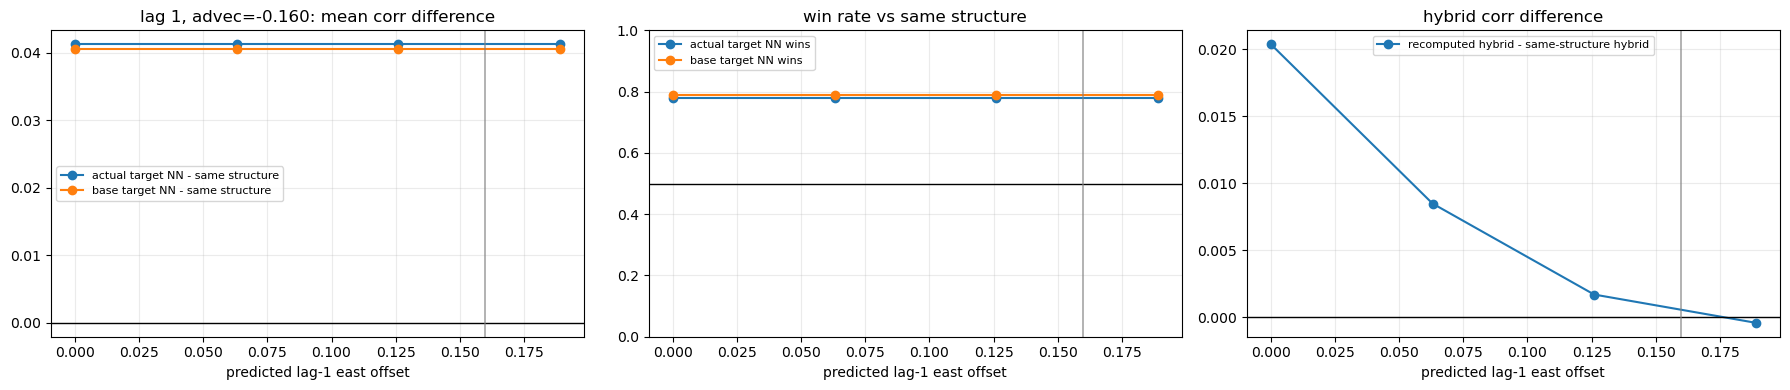

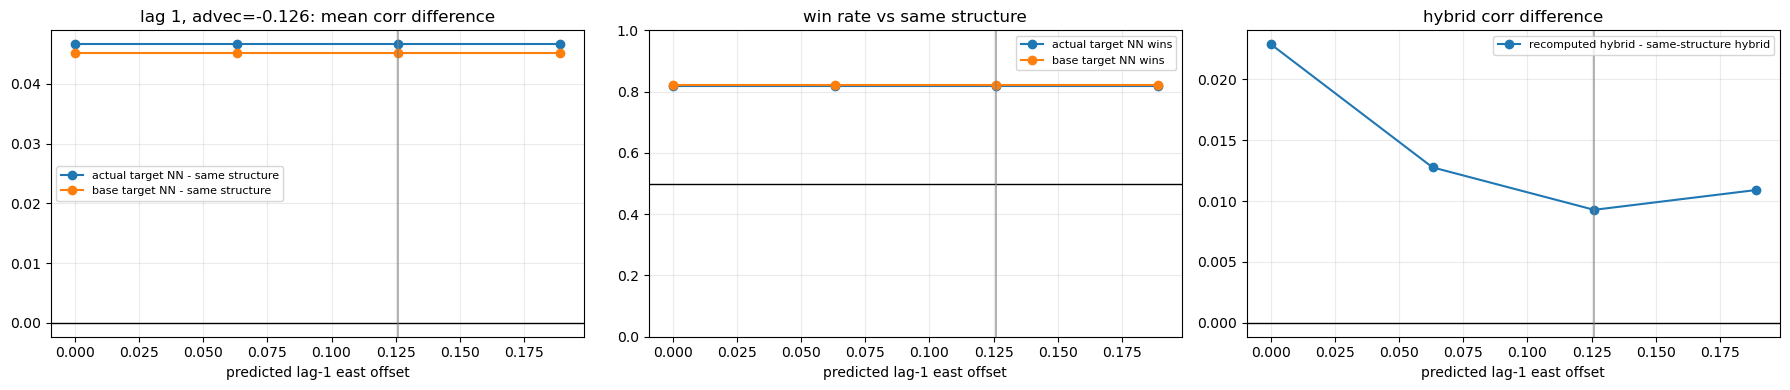

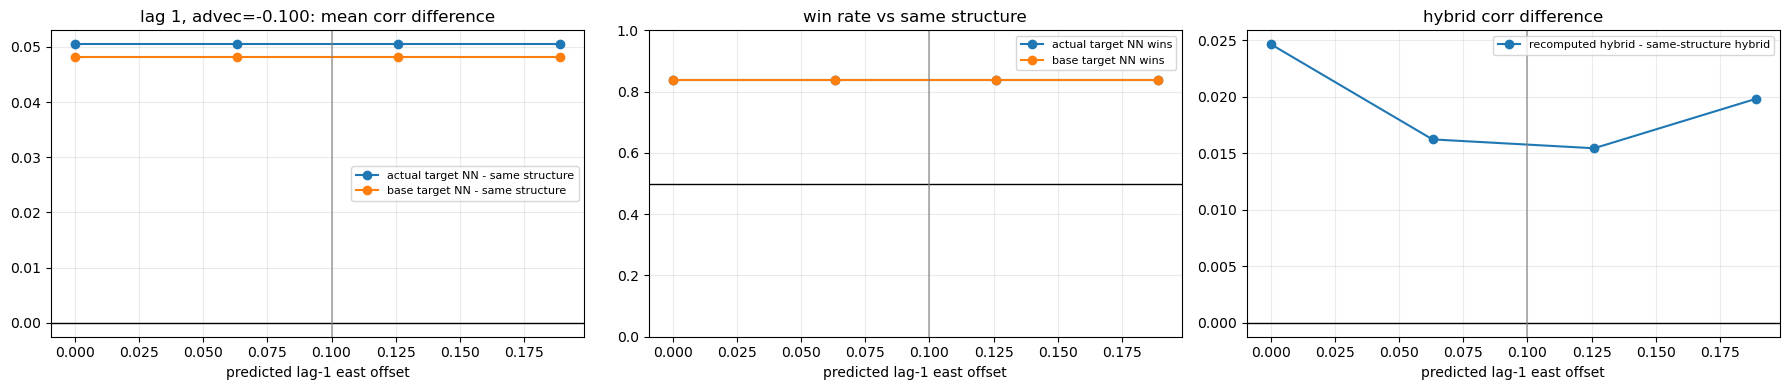

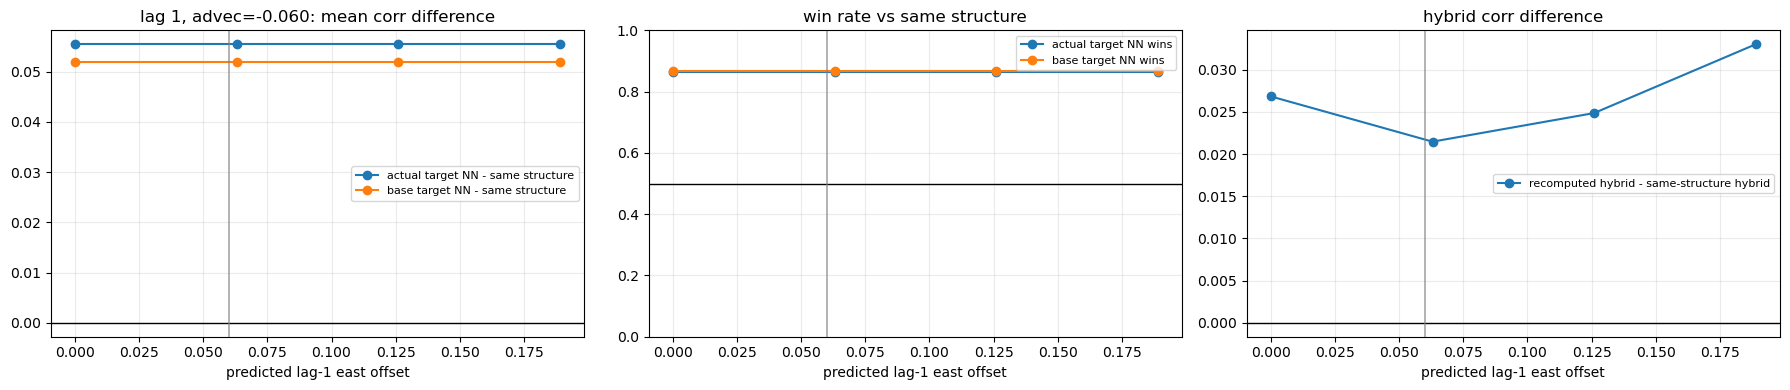

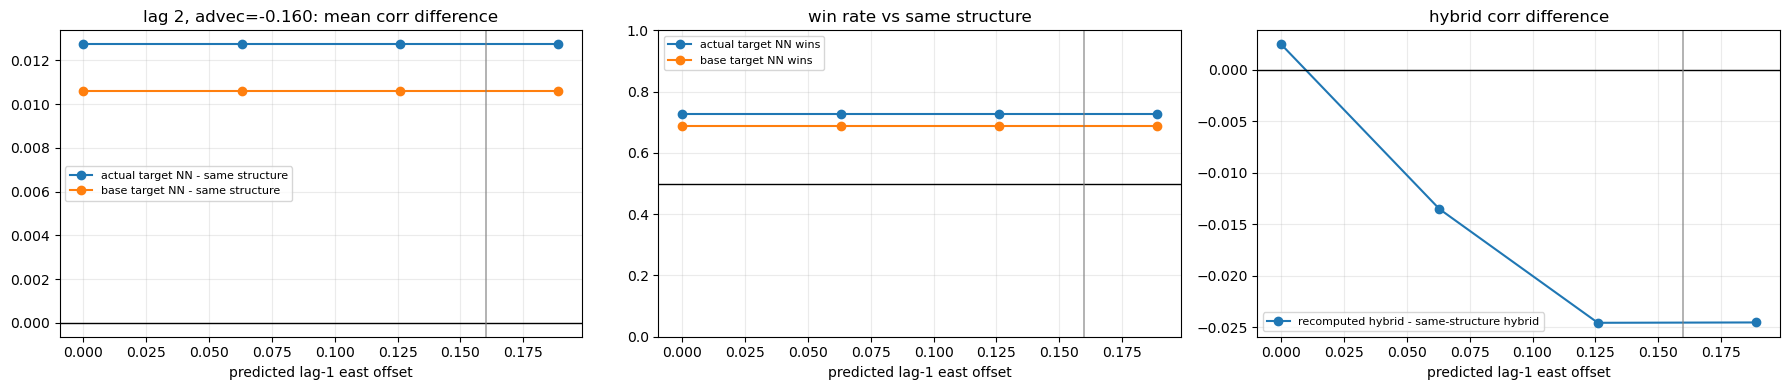

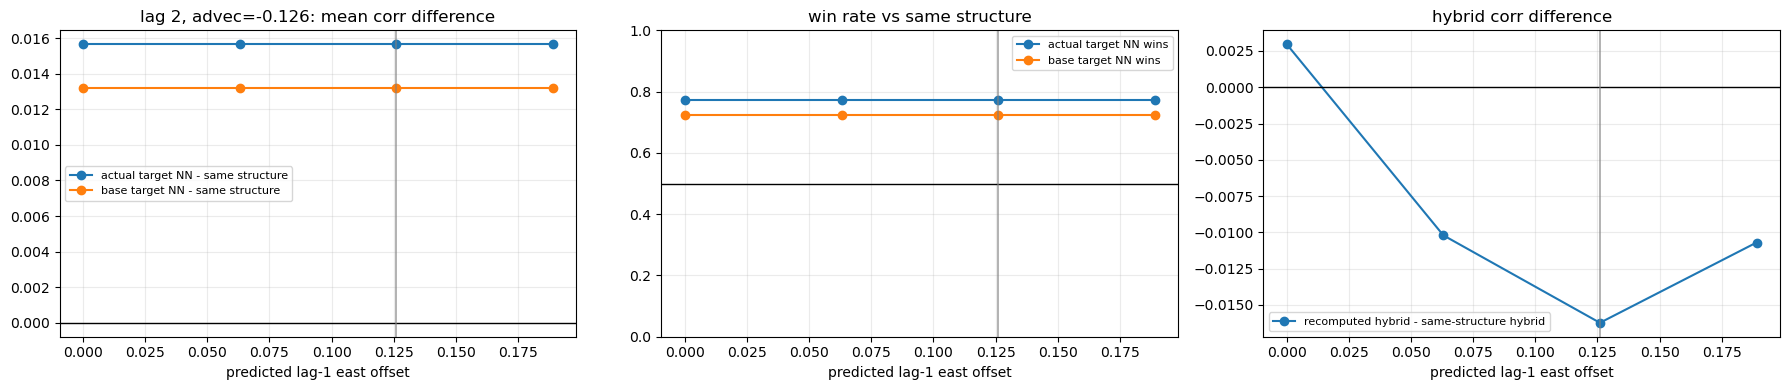

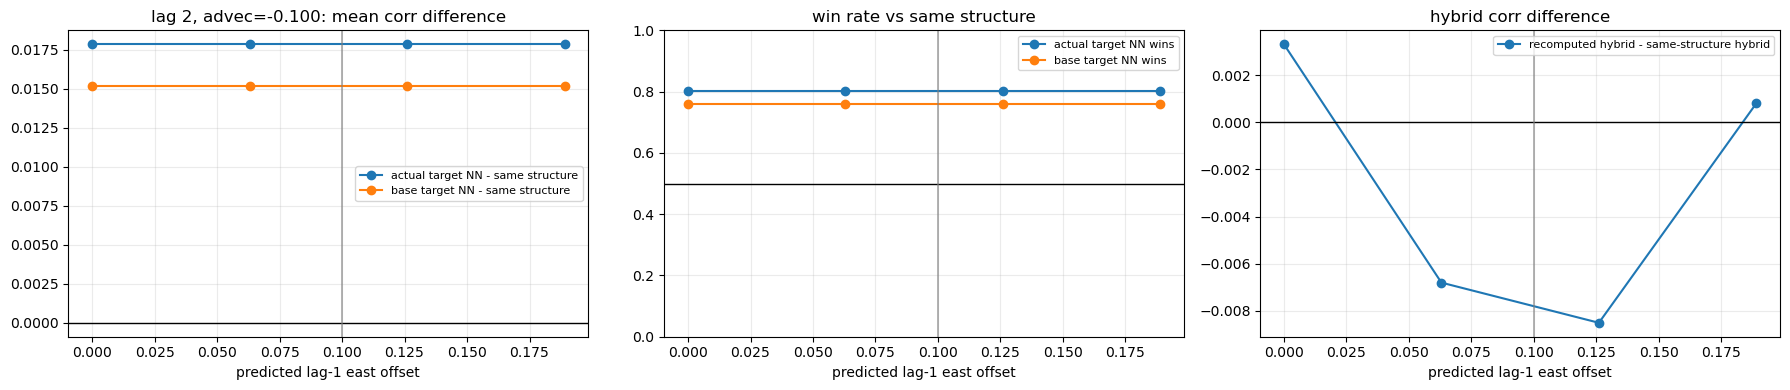

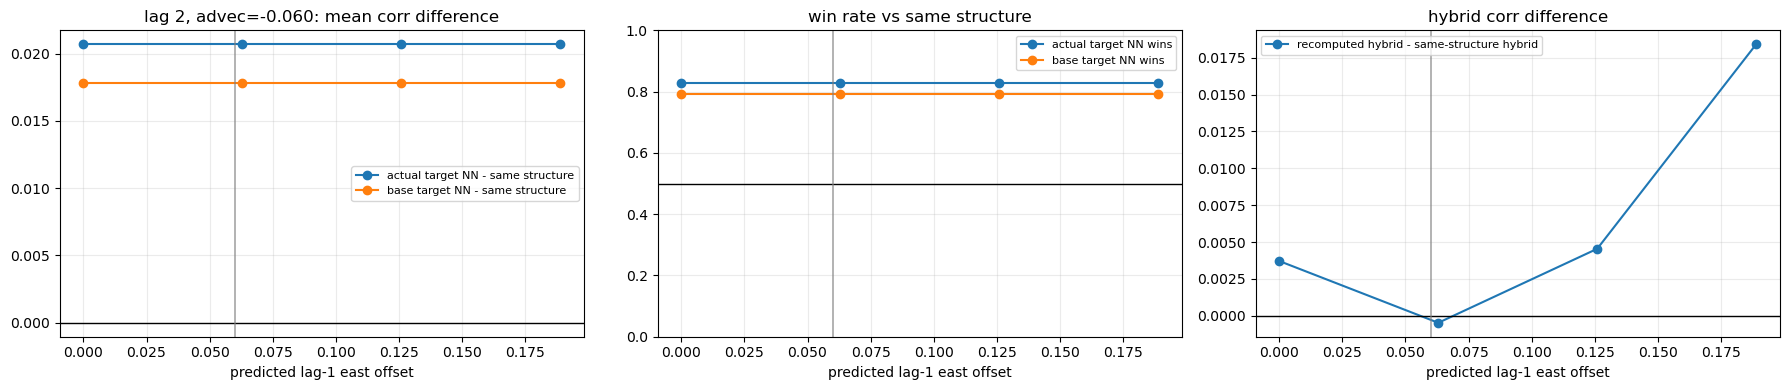

In [12]:
for lag in sorted(pair_summary["lag"].unique()):
    for true_lon, sub in pair_summary[pair_summary["lag"] == lag].groupby("true_advec_lon", sort=True):
        sub = sub.sort_values("pred_lag1_offset")
        fig, axes = plt.subplots(1, 3, figsize=(18, 4))
        axes[0].plot(sub["pred_lag1_offset"], sub["actual_recompute_minus_same_anchor_mean"], marker="o", label="actual target NN - same structure")
        axes[0].plot(sub["pred_lag1_offset"], sub["base_recompute_minus_same_anchor_mean"], marker="o", label="base target NN - same structure")
        axes[0].axhline(0, color="black", linewidth=1)
        axes[0].set_title(f"lag {lag}, advec={true_lon:.3f}: mean corr difference")
        axes[0].set_xlabel("predicted lag-1 east offset")
        axes[0].legend(fontsize=8)

        axes[1].plot(sub["pred_lag1_offset"], sub["actual_recompute_gt_same_anchor_rate"], marker="o", label="actual target NN wins")
        axes[1].plot(sub["pred_lag1_offset"], sub["base_recompute_gt_same_anchor_rate"], marker="o", label="base target NN wins")
        axes[1].axhline(0.5, color="black", linewidth=1)
        axes[1].set_ylim(0, 1)
        axes[1].set_title("win rate vs same structure")
        axes[1].set_xlabel("predicted lag-1 east offset")
        axes[1].legend(fontsize=8)

        axes[2].plot(sub["pred_lag1_offset"], sub["hybrid_recompute_minus_hybrid_same_mean"], marker="o", label="recomputed hybrid - same-structure hybrid")
        axes[2].axhline(0, color="black", linewidth=1)
        axes[2].set_title("hybrid corr difference")
        axes[2].set_xlabel("predicted lag-1 east offset")
        axes[2].legend(fontsize=8)

        for ax in axes:
            ax.axvline(abs(true_lon), color="gray", linewidth=1.2, alpha=0.7)
            ax.grid(alpha=0.25)
        plt.tight_layout()
        plt.show()

## Single-Target Inspection

Use this to inspect an individual target where the two strategies differ. Change `INSPECT_*` values after looking at the pairwise summary.

In [13]:
INSPECT_LAG = 1
INSPECT_TRUE_ADVEC_LON = -0.126
INSPECT_PRED_OFFSET = 0.126
INSPECT_TARGET_ORDER_IDX = int(eligible[len(eligible) // 2])

lag = INSPECT_LAG
lag_t_idx = TARGET_T_IDX - lag
true_dict = make_true_dict(INSPECT_TRUE_ADVEC_LON)
pred_shift = abs(INSPECT_PRED_OFFSET) * lag
cand_coords = coords_by_t[lag_t_idx]
cand_valid = valid_by_t[lag_t_idx]
valid_indices = np.where(cand_valid)[0]
valid_coords = cand_coords[valid_indices]
cand_tree = make_valid_obs_tree(valid_coords)
center_lookup = build_shift_lookup_base(INSPECT_PRED_OFFSET, multiplier=lag)
i = INSPECT_TARGET_ORDER_IDX
target_actual = t_coords[i]
target_base = ordered_base_coords[i]

corr = np.full(len(ordered_base_coords), -np.inf, dtype=np.float64)
corr[valid_indices] = latent_corr_current_to_candidate(target_actual, valid_coords, dt=float(lag), true_dict=true_dict)
top_idx = topk_corr_indices(corr, TOP_K_BY_LAG[lag])
ranks = ranks_from_corr(corr)

k_main = LAG_SET_SIZE[lag]
center_idx = int(center_lookup[i])
same_anchor = clean_unique([i, *list(nns_grid[i])], valid_mask=cand_valid, k=k_main)
recompute_actual = clean_unique(query_valid_obs_tree(target_actual, cand_tree, valid_indices, k=k_main + 8), valid_mask=cand_valid, k=k_main)
recompute_base = clean_unique(query_valid_obs_tree(target_base, cand_tree, valid_indices, k=k_main + 8), valid_mask=cand_valid, k=k_main)
fresh_same = clean_unique([center_idx, *list(nns_grid[center_idx])], valid_mask=cand_valid, k=k_main)
shifted_actual_query = target_actual.copy(); shifted_actual_query[1] += pred_shift
recompute_shifted = clean_unique(query_valid_obs_tree(shifted_actual_query, cand_tree, valid_indices, k=k_main + 8), valid_mask=cand_valid, k=k_main)

def inspect_table(label, idx):
    idx = np.asarray(idx, dtype=np.int64)
    return pd.DataFrame({
        "set": label,
        "order_idx": idx,
        "lat": cand_coords[idx, 0],
        "lon": cand_coords[idx, 1],
        "base_lat": ordered_base_coords[idx, 0],
        "base_lon": ordered_base_coords[idx, 1],
        "corr": corr[idx],
        "rank": ranks[idx],
        "dist_to_target_actual": np.sqrt(((cand_coords[idx] - target_actual[None, :]) ** 2).sum(axis=1)),
    })

inspect_df = pd.concat([
    inspect_table("corr_top", top_idx),
    inspect_table("same_structure_anchor_plus_nn", same_anchor),
    inspect_table("lag_recompute_actual_target_nn", recompute_actual),
    inspect_table("lag_recompute_base_target_nn", recompute_base),
    inspect_table("fresh_shift_center_same_structure", fresh_same),
    inspect_table("lag_recompute_actual_shifted_nn", recompute_shifted),
], ignore_index=True)

print("target order idx:", i)
print("target actual coord:", target_actual)
print("target matched base coord:", target_base)
print("candidate lag:", lag, "candidate time idx:", lag_t_idx)
display(inspect_df.sort_values(["set", "rank"]))

target order idx: 8990
target actual coord: [ -2.0040822 123.713394 ]
target matched base coord: [ -1.988 123.709]
candidate lag: 1 candidate time idx: 3


,set,order_idx,lat,lon,base_lat,base_lon,corr,rank,dist_to_target_actual
0,corr_top,5218,-2.101316,123.841930,-2.120,123.835,0.604515,1,0.161170
1,corr_top,9877,-2.057874,123.842610,-2.076,123.835,0.601916,2,0.139966
2,corr_top,10272,-2.101062,123.780780,-2.120,123.772,0.592091,3,0.118093
3,corr_top,9850,-2.057621,123.781460,-2.076,123.772,0.589798,4,0.086599
4,corr_top,10299,-2.101358,123.905785,-2.120,123.898,0.588625,5,0.215585
...,...,...,...,...,...,...,...,...,...
34,same_structure_anchor_plus_nn,2453,-1.862411,123.845634,-1.856,123.835,0.409707,71,0.193799
29,same_structure_anchor_plus_nn,1209,-1.905392,123.596085,-1.900,123.583,0.372579,95,0.153301
27,same_structure_anchor_plus_nn,4840,-1.861946,123.658676,-1.856,123.646,0.367440,97,0.152305
35,same_structure_anchor_plus_nn,7303,-1.818721,123.785160,-1.812,123.772,0.358768,104,0.198769


## Reading Guide

The notebook answers the local-structure question in layers:

- If `actual_recompute_minus_same_anchor_mean` is near zero and win rate is near 0.5, then reusing the same local graph is not costing much after high-resolution regridding.
- If it is consistently positive, then the same-structure lag local set is probably too rigid for irregular real locations.
- If `base_recompute_minus_same_anchor_mean` is smaller than `actual_recompute_minus_same_anchor_mean`, the gap is driven by actual-location irregularity rather than just the regular base target coordinate.
- If `hybrid_recompute_minus_hybrid_same_mean` is near zero even when pure local recompute wins, the hybrid shifted/fresh piece may already be absorbing most of the lost local geometry.

Interpretation should stay conservative: this is a geometry/correlation diagnostic, not a full likelihood fit. The next step, only if the diagnostic shows a meaningful gap, is to implement a frozen `LagRecomputeNN` Vecchia kernel and compare it against `SameStructure` in a short MC fit.